# 05 — TensorRT Inference: FP32 / FP16 / INT8 / FP8 / INT4

This notebook runs the full TRT pipeline for each precision mode:
1. Export model to ONNX (skipped if already on disk)
2. Build TensorRT engine (skipped if already on disk)
3. Run evaluation and collect metrics
4. Compare accuracy, latency, and throughput across precisions

**FP8 and INT4** require a QDQ-annotated ONNX from `modelopt` — run `quant_modelopt.py` first.  
**INT8** uses entropy calibration — runner wires the calibrator automatically.

## Setup

In [1]:
import sys
from pathlib import Path

# Make sure src/ is on the path
SRC = Path("..").resolve() / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
import matplotlib.pyplot as plt

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs, print_run_summary
from plots import plot_tradeoff_with_pareto, plot_tradeoff_scatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.3f}".format)

## Base config
All TRT runs share this base. Each precision overrides only `model_precision`.

In [2]:
base = ExperimentConfig(
    backend          = "tensorrt",
    device           = "cuda",
    batch_size       = 1,
    model_precision  = "fp32",   # overridden per run below
    input_quant_bits = 8,
    trt_static_shape = True,
    trt_workspace_mb = 2048,
    trt_calib_num_batches = 32,  # used only for INT8
    num_eval_batches = 1000,     # None = full val set
    seed             = 42,
)

## FP32

In [3]:
cfg_fp32 = with_overrides(base, model_precision="fp32")
payload_fp32, tracker_fp32 = run_experiment(cfg_fp32)
print_run_summary(payload_fp32)

[runner] Step 1/3 — Exporting to ONNX ...


/home/pf4636/code/resnet/quantized_resnets/src/onnx_exporter.py:28: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0305 16:15:48.091000 2777956 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[onnx_exporter] Exporting to /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx ...


W0305 16:15:48.423000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:15:48.424000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:15:48.425000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0305 16:15:48.426000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/pf4636/code/res

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.
[onnx_exporter] Saved (0.1 MB)
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 1000 batches ...
  [10/1000]  Top-1: 80.00%  Top-5: 100.00%  Infer: 1.25 ms/batch
  [20/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 1.07 ms/batch
  [30/1000]  Top-1: 90.00%  Top-5: 96.67%  Infer: 1.03 ms/batch
  [40/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.99 ms/batch
  [50/1000]  Top-1: 88.00%  Top-5: 96.00%  Infer: 0.97 ms/batch
  [60/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.95 ms/batch


## FP16

In [4]:
cfg_fp16 = with_overrides(base, model_precision="fp16")
payload_fp16, tracker_fp16 = run_experiment(cfg_fp16)
print_run_summary(payload_fp16)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 1000 batches ...
  [10/1000]  Top-1: 80.00%  Top-5: 100.00%  Infer: 0.56 ms/batch
  [20/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.51 ms/batch
  [30/1000]  Top-1: 90.00%  Top-5: 96.67%  Infer: 0.50 ms/batch
  [40/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.50 ms/batch
  [50/1000]  Top-1: 88.00%  Top-5: 96.00%  Infer: 0.50 ms/batch
  [60/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.50 ms/batch
  [70/1000]  Top-1: 84.29%  Top-5: 95.71%  Infer: 0.49 ms/batch
  [80/1000]  Top-1: 85.00%  Top-5: 95

## INT8
The runner automatically creates an `Int8EntropyCalibrator` from the val set.  
Calibration cache is saved to `engines/<run_id>.calib_cache` and reused on repeated runs.

In [5]:
cfg_int8 = with_overrides(base, model_precision="int8")
payload_int8, tracker_int8 = run_experiment(cfg_int8)
print_run_summary(payload_int8)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 1000 batches ...
  [10/1000]  Top-1: 80.00%  Top-5: 100.00%  Infer: 0.85 ms/batch
  [20/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.71 ms/batch
  [30/1000]  Top-1: 90.00%  Top-5: 96.67%  Infer: 0.72 ms/batch
  [40/1000]  Top-1: 85.00%  Top-5: 97.50%  Infer: 0.72 ms/batch
  [50/1000]  Top-1: 88.00%  Top-5: 98.00%  Infer: 0.71 ms/batch
  [60/1000]  Top-1: 86.67%  Top-5: 96.67%  Infer: 0.70 ms/batch
  [70/1000]  Top-1: 87.14%  Top-5: 97.14%  Infer: 0.70 ms/batch
  [80/1000]  Top-1: 87.50%  Top-5: 96

## FP8
Requires `onnx/resnet18_fp8_qdq.onnx` — generated by `quant_modelopt.py`.  
No calibrator needed; quantization scales are embedded in the ONNX Q/DQ nodes.

In [6]:
cfg_fp8 = with_overrides(base, model_precision="fp8")
payload_fp8, tracker_fp8 = run_experiment(cfg_fp8)
print_run_summary(payload_fp8)

[runner] Step 1/3 — Exporting to ONNX ...


/home/pf4636/code/resnet/quantized_resnets/src/onnx_exporter.py:28: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0305 16:16:00.892000 2777956 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[onnx_exporter] Exporting to /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_fp8_qdq.onnx ...


W0305 16:16:01.040000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:16:01.041000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:16:01.042000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0305 16:16:01.043000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/pf4636/code/res

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.
[onnx_exporter] Saved (0.1 MB)
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 1000 batches ...
  [10/1000]  Top-1: 80.00%  Top-5: 100.00%  Infer: 21.00 ms/batch
  [20/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 18.22 ms/batch
  [30/1000]  Top-1: 90.00%  Top-5: 96.67%  Infer: 17.29 ms/batch
  [40/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 16.82 ms/batch
  [50/1000]  Top-1: 88.00%  Top-5: 96.00%  Infer: 16.55 ms/batch
  [60/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 16.38 ms/ba

## INT4 (weights-only)
Requires `onnx/resnet18_int4_qdq.onnx` — generated by `quant_modelopt.py`.  
Weights are quantized to INT4; activations remain FP16.

In [7]:
cfg_int4 = with_overrides(base, model_precision="int4")
payload_int4, tracker_int4 = run_experiment(cfg_int4)
print_run_summary(payload_int4)

/home/pf4636/code/resnet/quantized_resnets/src/onnx_exporter.py:28: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0305 16:16:21.654000 2777956 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[runner] Step 1/3 — Exporting to ONNX ...
[onnx_exporter] Exporting to /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_int4_qdq.onnx ...


W0305 16:16:21.803000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:16:21.803000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0305 16:16:21.804000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0305 16:16:21.805000 2777956 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/pf4636/code/res

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.
[onnx_exporter] Saved (0.1 MB)
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 1000 batches ...
  [10/1000]  Top-1: 80.00%  Top-5: 100.00%  Infer: 0.51 ms/batch
  [20/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.53 ms/batch
  [30/1000]  Top-1: 90.00%  Top-5: 96.67%  Infer: 0.49 ms/batch
  [40/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.47 ms/batch
  [50/1000]  Top-1: 88.00%  Top-5: 96.00%  Infer: 0.46 ms/batch
  [60/1000]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.47 ms/batch


---
## Results

### Summary table

In [8]:
runs = load_runs("../runs")
df   = pd.DataFrame(flatten_runs(runs))

# Keep only TensorRT runs, select the columns that matter
COLS = [
    "cfg.model_precision",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.infer_ms_std",
    "res.throughput_infer_sps",
    "res.total_samples",
]

PRECISION_ORDER = ["fp32", "fp16", "int8", "fp8", "int4"]

df_trt = (
    df[df["cfg.backend"] == "tensorrt"][COLS]
    .drop_duplicates(subset="cfg.model_precision", keep="last")
    .set_index("cfg.model_precision")
    .reindex([p for p in PRECISION_ORDER if p in df["cfg.model_precision"].values])
)

df_trt.columns = ["Top-1 (%)", "Top-5 (%)", "Infer ms (avg)", "Infer ms (std)", "Throughput (sps)", "Samples"]
df_trt

,Top-1 (%),Top-5 (%),Infer ms (avg),Infer ms (std),Throughput (sps),Samples
cfg.model_precision,,,,,,
fp32,84.800,95.900,0.917,0.135,1090.933,1000
fp16,84.700,95.900,0.454,0.173,2200.601,1000
int8,85.000,96.000,0.755,0.328,1323.810,1000
fp8,84.800,95.900,15.636,0.735,63.957,1000
int4,84.700,95.900,0.486,0.190,2058.930,1000


### Accuracy drop and speedup vs FP32 baseline

In [14]:
if "fp32" in df_trt.index:
    fp32_top1 = df_trt.loc["fp32", "Top-1 (%)"]
    fp32_ms   = df_trt.loc["fp32", "Infer ms (avg)"]

    summary = df_trt[["Top-1 (%)", "Infer ms (avg)"]].copy()
    summary["ΔTop-1 (pp)"]  = summary["Top-1 (%)"]      - fp32_top1
    summary["Speedup vs FP32"] = fp32_ms / summary["Infer ms (avg)"]
    print(summary.to_string())
else:
    print("FP32 run not found — run cfg_fp32 cell first.")

                     Top-1 (%)  Infer ms (avg)  ΔTop-1 (pp)  Speedup vs FP32
cfg.model_precision                                                         
fp32                    84.800           0.917        0.000            1.000
fp16                    84.700           0.454       -0.100            2.017
int8                    85.000           0.755        0.200            1.213
fp8                     84.800          15.636        0.000            0.059
int4                    84.700           0.486       -0.100            1.887


### Accuracy vs Latency (scatter)

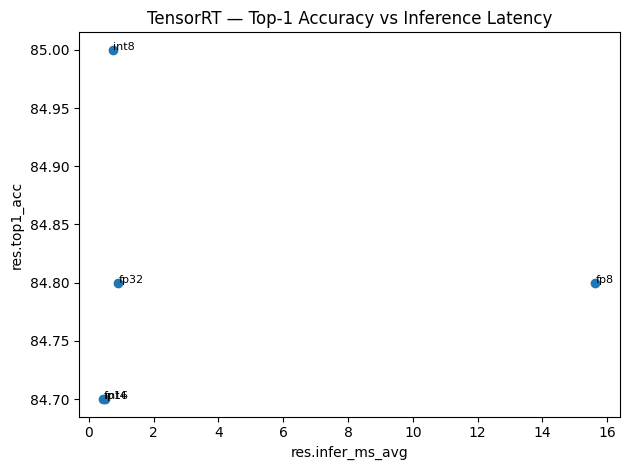

In [10]:
rows_trt = [r for r in flatten_runs(runs) if r.get("cfg.backend") == "tensorrt"]

plot_tradeoff_scatter(
    rows_trt,
    x_key  = "res.infer_ms_avg",
    y_key  = "res.top1_acc",
    label_keys = ("cfg.model_precision",),
    title  = "TensorRT — Top-1 Accuracy vs Inference Latency",
    annotate = True,
)

### Accuracy–Latency Pareto frontier

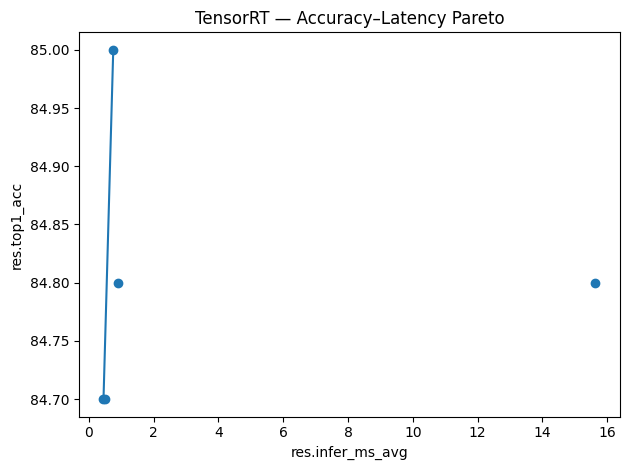

In [11]:
plot_tradeoff_with_pareto(
    rows_trt,
    x_key = "res.infer_ms_avg",
    y_key = "res.top1_acc",
    title = "TensorRT — Accuracy–Latency Pareto",
)

### Throughput bar chart

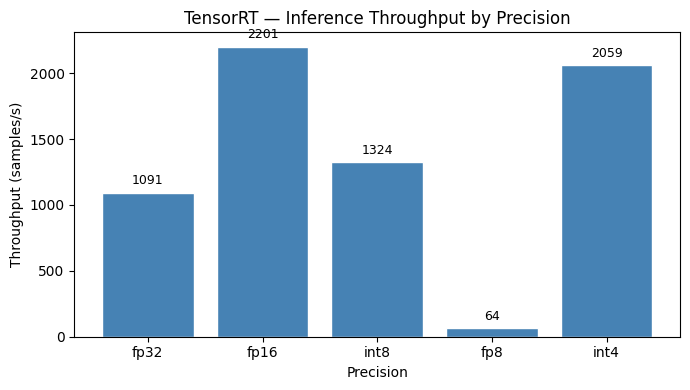

In [12]:
df_plot = df_trt["Throughput (sps)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_plot.index, df_plot.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="{:.0f}", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Throughput (samples/s)")
ax.set_title("TensorRT — Inference Throughput by Precision")
plt.tight_layout()
plt.show()

### Latency bar chart

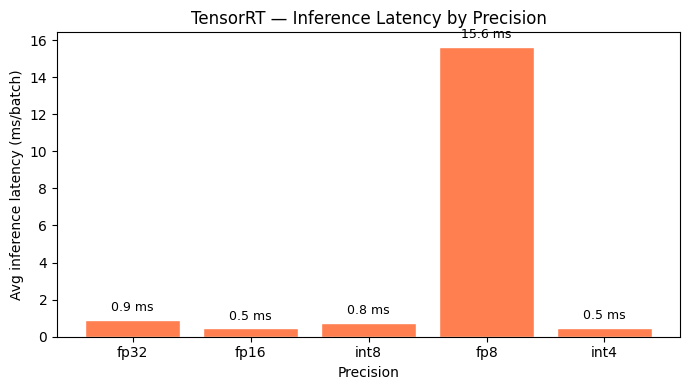

In [13]:
df_lat = df_trt["Infer ms (avg)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_lat.index, df_lat.values, color="coral", edgecolor="white")
ax.bar_label(bars, fmt="{:.1f} ms", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Avg inference latency (ms/batch)")
ax.set_title("TensorRT — Inference Latency by Precision")
plt.tight_layout()
plt.show()